CUSTOMER BEHAVIOUR ANALYSIS

Sessions:  1,087,262
Customers: 8,000
Stations:  150

Data validation: PASSED

Completed sessions:
1,068,272

Session status:
session_status
Completed    1068272
Cancelled      12331
Failed          6659
Name: count, dtype: int64

OVERALL CHARGING BEHAVIOUR

Peak-session share: 31.1%
Weekend-session share: 29.3%

CUSTOMER SEGMENT BEHAVIOUR
 customer_segment  customers  avg_sessions  avg_energy_kwh  avg_peak_share  avg_flexibility_score  intervention_eligible  eligible_share
Convenience_First       1991        76.538        1967.531           0.322                 64.967                    585           0.294
     High_Mileage        794       380.777       11305.304           0.306                 68.494                     66           0.083
  Price_Sensitive       2036        96.953        2136.940           0.298                 67.547                    348           0.171
 Routine_Commuter       3179       130.906        3069.302           0.316       

/var/folders/pb/0kdhsl4d4q1d6klyp9ctdg2r0000gn/T/ipykernel_7349/1189996983.py:259: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_entropy)


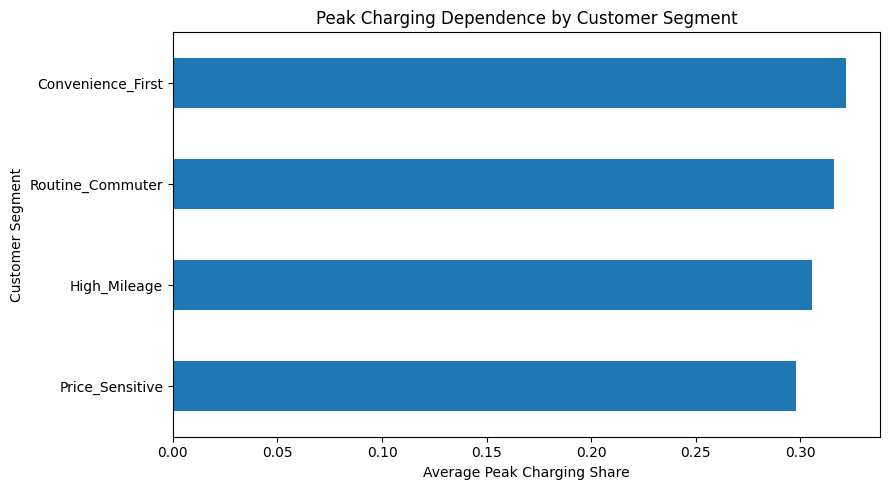

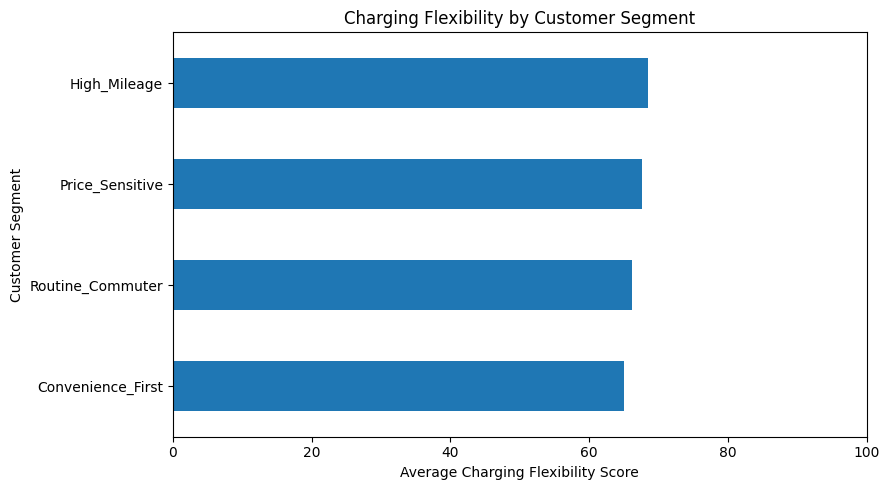

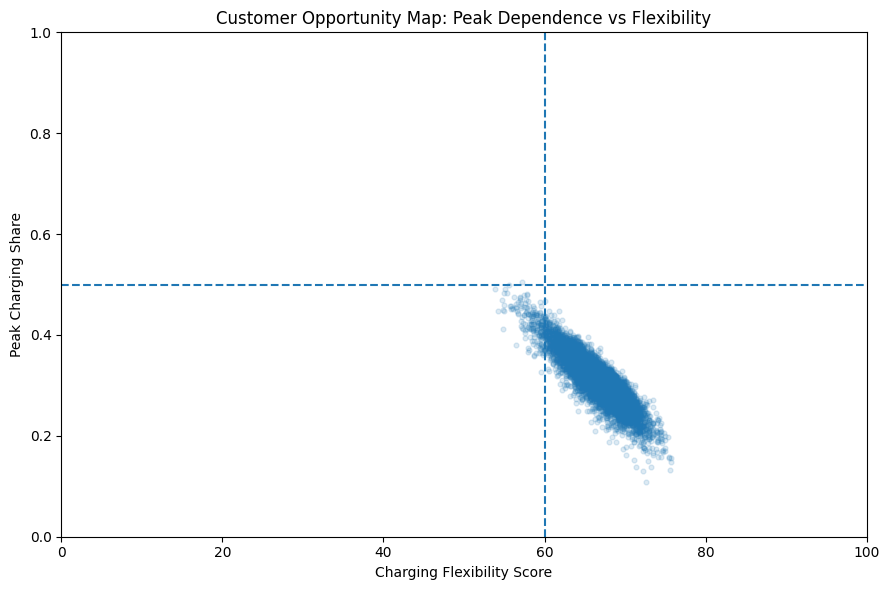

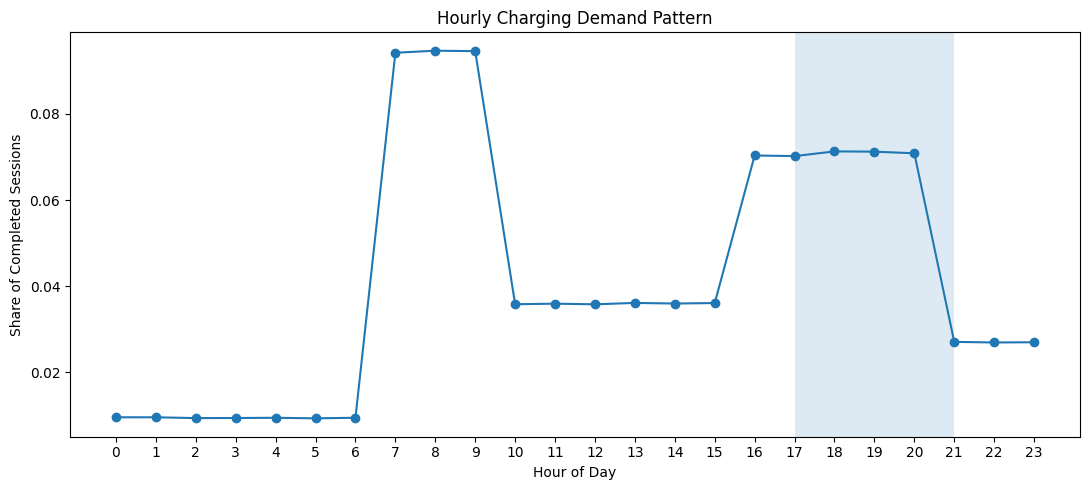


CUSTOMER BEHAVIOUR ANALYSIS COMPLETE

Customers analysed: 8,000
Eligible for intervention: 1,823
Eligible customer share: 22.8%

Average flexibility score: 66.5/100

Average peak charging share: 31.2%

Outputs saved:
 - outputs/tables/customer_behaviour.csv
 - outputs/tables/customer_segment_behaviour.csv
 - outputs/tables/peak_dependence_summary.csv
 - outputs/tables/city_intervention_opportunity.csv
 - outputs/tables/top_intervention_targets.csv

Customer Behaviour & Segmentation stage complete.


In [3]:
# ============================================================
# 03_customer_behaviour.ipynb
# Customer Behaviour, Peak Dependence & Charging Flexibility
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


# ============================================================
# 1. SETUP
# ============================================================

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_PATH = Path("../data/raw")
OUTPUT_FIGURES = Path("../outputs/figures")
OUTPUT_TABLES = Path("../outputs/tables")

OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)

SESSIONS_PATH = DATA_PATH / "sessions.csv"
CUSTOMERS_PATH = DATA_PATH / "customers.csv"
STATIONS_PATH = DATA_PATH / "stations.csv"


# ============================================================
# 2. LOAD DATA
# ============================================================

sessions = pd.read_csv(SESSIONS_PATH)
customers = pd.read_csv(CUSTOMERS_PATH)
stations = pd.read_csv(STATIONS_PATH)

sessions["start_timestamp"] = pd.to_datetime(
    sessions["start_timestamp"]
)

print("=" * 65)
print("CUSTOMER BEHAVIOUR ANALYSIS")
print("=" * 65)

print(f"\nSessions:  {len(sessions):,}")
print(f"Customers: {len(customers):,}")
print(f"Stations:  {len(stations):,}")


# ============================================================
# 3. BASIC DATA VALIDATION
# ============================================================

assert sessions["session_id"].is_unique
assert customers["customer_id"].is_unique
assert stations["station_id"].is_unique

assert sessions["customer_id"].isin(
    customers["customer_id"]
).all()

assert sessions["station_id"].isin(
    stations["station_id"]
).all()

assert sessions["start_timestamp"].notna().all()

print("\nData validation: PASSED")


# ============================================================
# 4. CREATE TIME FEATURES
# ============================================================

sessions["hour"] = sessions["start_timestamp"].dt.hour

sessions["day_of_week"] = (
    sessions["start_timestamp"].dt.dayofweek
)

sessions["day_name"] = (
    sessions["start_timestamp"].dt.day_name()
)

sessions["month"] = (
    sessions["start_timestamp"].dt.month
)

sessions["is_weekend"] = (
    sessions["day_of_week"] >= 5
)

sessions["is_weekday"] = (
    sessions["day_of_week"] < 5
)


# ============================================================
# 5. DEFINE PEAK / OFF-PEAK WINDOWS
# ============================================================

# Business assumption:
# Evening 17:00-22:00 represents the main system peak-risk
# period for public EV charging.
#
# This is an analytical definition, not a claim about an
# official Tata Power tariff or grid tariff.

sessions["is_peak"] = (
    sessions["hour"].between(17, 21)
)

sessions["is_off_peak"] = (
    ~sessions["is_peak"]
)

sessions["time_bucket"] = pd.cut(
    sessions["hour"],
    bins=[-1, 6, 11, 16, 21, 23],
    labels=[
        "Night",
        "Morning",
        "Afternoon",
        "Evening_Peak",
        "Late_Evening"
    ]
)


# ============================================================
# 6. FOCUS ON COMPLETED SESSIONS
# ============================================================

completed_sessions = sessions[
    sessions["session_status"] == "Completed"
].copy()

print("\nCompleted sessions:")
print(f"{len(completed_sessions):,}")

print("\nSession status:")
print(
    sessions["session_status"]
    .value_counts()
)


# ============================================================
# 7. OVERALL PEAK / OFF-PEAK BEHAVIOUR
# ============================================================

overall_peak_share = (
    completed_sessions["is_peak"].mean()
)

overall_weekend_share = (
    completed_sessions["is_weekend"].mean()
)

print("\n" + "=" * 65)
print("OVERALL CHARGING BEHAVIOUR")
print("=" * 65)

print(
    f"\nPeak-session share: "
    f"{overall_peak_share:.1%}"
)

print(
    f"Weekend-session share: "
    f"{overall_weekend_share:.1%}"
)


# ============================================================
# 8. CUSTOMER-LEVEL BEHAVIOUR
# ============================================================

customer_sessions = (
    completed_sessions
    .groupby("customer_id")
    .agg(
        total_sessions=("session_id", "count"),
        total_energy_kwh=("energy_kwh", "sum"),
        avg_energy_kwh=("energy_kwh", "mean"),
        avg_duration_minutes=("duration_minutes", "mean"),
        peak_sessions=("is_peak", "sum"),
        weekend_sessions=("is_weekend", "sum"),
    )
    .reset_index()
)

customer_sessions["peak_share"] = (
    customer_sessions["peak_sessions"]
    / customer_sessions["total_sessions"]
)

customer_sessions["weekend_share"] = (
    customer_sessions["weekend_sessions"]
    / customer_sessions["total_sessions"]
)


# ============================================================
# 9. CUSTOMER HOURLY DISTRIBUTION
# ============================================================

hourly_counts = (
    completed_sessions
    .groupby(["customer_id", "hour"])
    .size()
    .reset_index(name="sessions")
)

hourly_counts["hour_share"] = (
    hourly_counts["sessions"]
    / hourly_counts.groupby("customer_id")["sessions"]
      .transform("sum")
)


# ============================================================
# 10. CALCULATE TIME-DIVERSITY / ENTROPY
# ============================================================

# A customer who charges across many different hours has
# greater temporal diversity than someone concentrated into
# one narrow period.
#
# Shannon entropy is normalized to 0-100.
# Higher score = more diverse charging timing.
#
# This is used as a behavioural proxy for flexibility,
# NOT as proof that the customer will shift behaviour.

def calculate_entropy(group):

    probabilities = group["hour_share"].values

    entropy = -np.sum(
        probabilities * np.log2(probabilities)
    )

    # Maximum entropy across 24 hours
    max_entropy = np.log2(24)

    normalized_entropy = (
        entropy / max_entropy
    )

    return normalized_entropy * 100


time_diversity = (
    hourly_counts
    .groupby("customer_id")
    .apply(calculate_entropy)
    .reset_index(name="time_diversity_score")
)


# ============================================================
# 11. MERGE CUSTOMER ATTRIBUTES
# ============================================================

customer_behaviour = (
    customer_sessions
    .merge(
        time_diversity,
        on="customer_id",
        how="left"
    )
    .merge(
        customers,
        on="customer_id",
        how="left"
    )
)


# ============================================================
# 12. SESSION FREQUENCY NORMALIZATION
# ============================================================

# Customers with very few sessions do not provide enough
# behavioural evidence for a reliable flexibility estimate.

customer_behaviour["behavioural_confidence"] = pd.cut(
    customer_behaviour["total_sessions"],
    bins=[0, 4, 9, 19, np.inf],
    labels=[
        "Low",
        "Moderate",
        "Good",
        "High"
    ]
)


# ============================================================
# 13. FLEXIBILITY COMPONENTS
# ============================================================

# Component 1:
# Off-peak charging behaviour.
#
# More off-peak activity = stronger evidence that the customer
# already uses multiple charging periods.

customer_behaviour["off_peak_share"] = (
    1 - customer_behaviour["peak_share"]
)

customer_behaviour["off_peak_score"] = (
    customer_behaviour["off_peak_share"] * 100
)


# Component 2:
# Temporal diversity.
#
# More diverse charging times = greater potential flexibility.

customer_behaviour["diversity_score"] = (
    customer_behaviour["time_diversity_score"]
)


# Component 3:
# Weekend charging diversity.
#
# Weekend activity indicates that charging demand is not
# exclusively tied to weekday commuting patterns.

customer_behaviour["weekend_score"] = (
    customer_behaviour["weekend_share"] * 100
)


# ============================================================
# 14. CHARGING FLEXIBILITY SCORE
# ============================================================

# Weighted behavioural proxy:
#
# 50% = off-peak usage
# 30% = temporal diversity
# 20% = weekend flexibility
#
# Score range: 0-100.
#
# IMPORTANT:
# This score represents OBSERVED FLEXIBILITY POTENTIAL.
# It does not prove willingness to shift charging.

customer_behaviour["flexibility_score"] = (
    0.50 * customer_behaviour["off_peak_score"]
    + 0.30 * customer_behaviour["diversity_score"]
    + 0.20 * customer_behaviour["weekend_score"]
)

customer_behaviour["flexibility_score"] = (
    customer_behaviour["flexibility_score"]
    .clip(0, 100)
    .round(1)
)


# ============================================================
# 15. FLEXIBILITY CATEGORIES
# ============================================================

customer_behaviour["flexibility_category"] = pd.cut(
    customer_behaviour["flexibility_score"],
    bins=[-1, 33, 66, 100],
    labels=[
        "Low Flexibility",
        "Moderate Flexibility",
        "High Flexibility"
    ]
)


# ============================================================
# 16. PEAK DEPENDENCE CATEGORY
# ============================================================

customer_behaviour["peak_dependence"] = pd.cut(
    customer_behaviour["peak_share"],
    bins=[-0.01, 0.33, 0.66, 1.01],
    labels=[
        "Low Peak Dependence",
        "Moderate Peak Dependence",
        "High Peak Dependence"
    ]
)


# ============================================================
# 17. TARGETABLE CUSTOMER SEGMENTS
# ============================================================

# The intervention opportunity is NOT simply:
# "customers who charge during peak."
#
# We want customers who:
#
# 1. rely significantly on peak charging
# 2. show evidence of temporal flexibility
# 3. have enough observed sessions for confidence
#
# This creates a more defensible intervention target.

peak_share_threshold = customer_behaviour["peak_share"].quantile(0.75)

customer_behaviour["intervention_eligible"] = (
    (customer_behaviour["peak_share"] >= peak_share_threshold)
    &
    (customer_behaviour["flexibility_score"] >= 60)
    &
    (customer_behaviour["total_sessions"] >= 5)
)


# ============================================================
# 18. PRIORITY LEVEL
# ============================================================

def assign_priority(row):

    if not row["intervention_eligible"]:
        return "Not Eligible"

    if (
        row["peak_share"] >= 0.70
        and row["flexibility_score"] >= 75
    ):
        return "High Priority"

    if (
        row["peak_share"] >= 0.60
        and row["flexibility_score"] >= 65
    ):
        return "Medium Priority"

    return "Low Priority"


customer_behaviour["intervention_priority"] = (
    customer_behaviour.apply(
        assign_priority,
        axis=1
    )
)


# ============================================================
# 19. SEGMENT-LEVEL BEHAVIOUR
# ============================================================

segment_summary = (
    customer_behaviour
    .groupby("customer_segment", observed=True)
    .agg(
        customers=("customer_id", "count"),
        avg_sessions=("total_sessions", "mean"),
        avg_energy_kwh=("total_energy_kwh", "mean"),
        avg_peak_share=("peak_share", "mean"),
        avg_flexibility_score=(
            "flexibility_score",
            "mean"
        ),
        intervention_eligible=(
            "intervention_eligible",
            "sum"
        )
    )
    .reset_index()
)

segment_summary["eligible_share"] = (
    segment_summary["intervention_eligible"]
    / segment_summary["customers"]
)


print("\n" + "=" * 65)
print("CUSTOMER SEGMENT BEHAVIOUR")
print("=" * 65)

print(
    segment_summary.round(3).to_string(
        index=False
    )
)


# ============================================================
# 20. PEAK DEPENDENCE SUMMARY
# ============================================================

peak_summary = (
    customer_behaviour
    .groupby("peak_dependence", observed=True)
    .agg(
        customers=("customer_id", "count"),
        avg_peak_share=("peak_share", "mean"),
        avg_flexibility=("flexibility_score", "mean"),
        eligible_customers=(
            "intervention_eligible",
            "sum"
        )
    )
    .reset_index()
)

print("\n" + "=" * 65)
print("PEAK DEPENDENCE")
print("=" * 65)

print(
    peak_summary.round(3).to_string(
        index=False
    )
)


# ============================================================
# 21. FLEXIBILITY DISTRIBUTION
# ============================================================

flexibility_summary = (
    customer_behaviour
    ["flexibility_category"]
    .value_counts()
    .sort_index()
)

print("\n" + "=" * 65)
print("FLEXIBILITY DISTRIBUTION")
print("=" * 65)

print(flexibility_summary)


# ============================================================
# 22. INTERVENTION TARGET SUMMARY
# ============================================================

eligible_customers = customer_behaviour[
    customer_behaviour["intervention_eligible"]
].copy()

print("\n" + "=" * 65)
print("INTERVENTION TARGETING")
print("=" * 65)

print(
    f"\nEligible customers: "
    f"{len(eligible_customers):,}"
)

print(
    f"Share of customers: "
    f"{len(eligible_customers) / len(customer_behaviour):.1%}"
)

print("\nPriority distribution:")

print(
    customer_behaviour[
        "intervention_priority"
    ].value_counts()
)


# ============================================================
# 23. TOP TARGET CUSTOMER PROFILES
# ============================================================

top_targets = (
    eligible_customers
    .sort_values(
        [
            "intervention_priority",
            "peak_share",
            "flexibility_score"
        ],
        ascending=[True, False, False]
    )
    [
        [
            "customer_id",
            "customer_segment",
            "total_sessions",
            "total_energy_kwh",
            "peak_share",
            "off_peak_share",
            "flexibility_score",
            "flexibility_category",
            "intervention_priority"
        ]
    ]
    .head(20)
)

print("\nTop intervention candidates:")

print(
    top_targets.to_string(
        index=False
    )
)


# ============================================================
# 24. CITY-LEVEL CUSTOMER OPPORTUNITY
# ============================================================

city_summary = (
    customer_behaviour
    .groupby("city", observed=True)
    .agg(
        customers=("customer_id", "count"),
        avg_peak_share=("peak_share", "mean"),
        avg_flexibility=("flexibility_score", "mean"),
        eligible_customers=(
            "intervention_eligible",
            "sum"
        ),
        total_energy_kwh=(
            "total_energy_kwh",
            "sum"
        )
    )
    .reset_index()
)

city_summary["eligible_share"] = (
    city_summary["eligible_customers"]
    / city_summary["customers"]
)

city_summary = city_summary.sort_values(
    "eligible_customers",
    ascending=False
)

print("\n" + "=" * 65)
print("CITY-LEVEL INTERVENTION OPPORTUNITY")
print("=" * 65)

print(
    city_summary.round(3).to_string(
        index=False
    )
)


# ============================================================
# 25. VISUALIZATION 1 — PEAK SHARE BY SEGMENT
# ============================================================

segment_plot = (
    customer_behaviour
    .groupby("customer_segment", observed=True)
    ["peak_share"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(9, 5))

segment_plot.plot(
    kind="barh"
)

plt.xlabel("Average Peak Charging Share")
plt.ylabel("Customer Segment")
plt.title(
    "Peak Charging Dependence by Customer Segment"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES / "peak_dependence_by_segment.png",
    dpi=150
)

plt.show()


# ============================================================
# 26. VISUALIZATION 2 — FLEXIBILITY BY SEGMENT
# ============================================================

flexibility_plot = (
    customer_behaviour
    .groupby("customer_segment", observed=True)
    ["flexibility_score"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(9, 5))

flexibility_plot.plot(
    kind="barh"
)

plt.xlabel("Average Charging Flexibility Score")
plt.ylabel("Customer Segment")
plt.title(
    "Charging Flexibility by Customer Segment"
)

plt.xlim(0, 100)

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES / "flexibility_by_segment.png",
    dpi=150
)

plt.show()


# ============================================================
# 27. VISUALIZATION 3 — PEAK DEPENDENCE VS FLEXIBILITY
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    customer_behaviour["flexibility_score"],
    customer_behaviour["peak_share"],
    alpha=0.15,
    s=12
)

plt.axvline(
    60,
    linestyle="--"
)

plt.axhline(
    0.50,
    linestyle="--"
)

plt.xlabel("Charging Flexibility Score")
plt.ylabel("Peak Charging Share")
plt.title(
    "Customer Opportunity Map: Peak Dependence vs Flexibility"
)

plt.xlim(0, 100)
plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES / "peak_vs_flexibility.png",
    dpi=150
)

plt.show()


# ============================================================
# 28. VISUALIZATION 4 — HOURLY CHARGING PATTERN
# ============================================================

hourly_pattern = (
    completed_sessions
    .groupby("hour")
    .size()
)

hourly_share = (
    hourly_pattern
    / hourly_pattern.sum()
)

plt.figure(figsize=(11, 5))

hourly_share.plot(
    kind="line",
    marker="o"
)

plt.axvspan(
    17,
    21,
    alpha=0.15
)

plt.xlabel("Hour of Day")
plt.ylabel("Share of Completed Sessions")
plt.title(
    "Hourly Charging Demand Pattern"
)

plt.xticks(range(24))

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES / "hourly_charging_pattern.png",
    dpi=150
)

plt.show()


# ============================================================
# 29. SAVE CUSTOMER-LEVEL ANALYTICS TABLE
# ============================================================

customer_output_columns = [
    "customer_id",
    "customer_segment",
    "city",
    "total_sessions",
    "total_energy_kwh",
    "avg_energy_kwh",
    "avg_duration_minutes",
    "peak_sessions",
    "peak_share",
    "off_peak_share",
    "weekend_share",
    "time_diversity_score",
    "flexibility_score",
    "flexibility_category",
    "peak_dependence",
    "behavioural_confidence",
    "intervention_eligible",
    "intervention_priority"
]

customer_behaviour[
    customer_output_columns
].to_csv(
    OUTPUT_TABLES / "customer_behaviour.csv",
    index=False
)


# ============================================================
# 30. SAVE SUMMARY TABLES
# ============================================================

segment_summary.to_csv(
    OUTPUT_TABLES / "customer_segment_behaviour.csv",
    index=False
)

peak_summary.to_csv(
    OUTPUT_TABLES / "peak_dependence_summary.csv",
    index=False
)

city_summary.to_csv(
    OUTPUT_TABLES / "city_intervention_opportunity.csv",
    index=False
)

top_targets.to_csv(
    OUTPUT_TABLES / "top_intervention_targets.csv",
    index=False
)


# ============================================================
# 31. FINAL VALIDATION
# ============================================================

assert (
    customer_behaviour["flexibility_score"]
    .between(0, 100)
    .all()
)

assert (
    customer_behaviour["peak_share"]
    .between(0, 1)
    .all()
)

assert (
    customer_behaviour["off_peak_share"]
    .between(0, 1)
    .all()
)

assert (
    customer_behaviour["intervention_eligible"]
    .isin([True, False])
    .all()
)

assert (
    customer_behaviour["customer_id"]
    .is_unique
)


# ============================================================
# 32. FINAL BUSINESS OUTPUT
# ============================================================

print("\n" + "=" * 65)
print("CUSTOMER BEHAVIOUR ANALYSIS COMPLETE")
print("=" * 65)

print(
    f"\nCustomers analysed: "
    f"{len(customer_behaviour):,}"
)

print(
    f"Eligible for intervention: "
    f"{customer_behaviour['intervention_eligible'].sum():,}"
)

print(
    f"Eligible customer share: "
    f"{customer_behaviour['intervention_eligible'].mean():.1%}"
)

print(
    "\nAverage flexibility score: "
    f"{customer_behaviour['flexibility_score'].mean():.1f}/100"
)

print(
    "\nAverage peak charging share: "
    f"{customer_behaviour['peak_share'].mean():.1%}"
)

print("\nOutputs saved:")

print(
    " - outputs/tables/customer_behaviour.csv"
)

print(
    " - outputs/tables/customer_segment_behaviour.csv"
)

print(
    " - outputs/tables/peak_dependence_summary.csv"
)

print(
    " - outputs/tables/city_intervention_opportunity.csv"
)

print(
    " - outputs/tables/top_intervention_targets.csv"
)

print("\nCustomer Behaviour & Segmentation stage complete.")

In [5]:
print("\nSEGMENT PEAK SHARE:")
print(
    customer_behaviour
    .groupby("customer_segment", observed=True)["peak_share"]
    .agg(["mean", "median", "max"])
    .round(3)
)

print("\nSEGMENT FLEXIBILITY:")
print(
    customer_behaviour
    .groupby("customer_segment", observed=True)["flexibility_score"]
    .agg(["mean", "median", "max"])
    .round(1)
)

print("\nPEAK SHARE DISTRIBUTION:")
print(
    customer_behaviour["peak_share"]
    .describe()
    .round(3)
)

print("\nFLEXIBILITY DISTRIBUTION:")
print(
    customer_behaviour["flexibility_score"]
    .describe()
    .round(1)
)


SEGMENT PEAK SHARE:
                    mean  median    max
customer_segment                       
Convenience_First  0.322   0.322  0.500
High_Mileage       0.306   0.306  0.386
Price_Sensitive    0.298   0.298  0.481
Routine_Commuter   0.316   0.315  0.505

SEGMENT FLEXIBILITY:
                   mean  median   max
customer_segment                     
Convenience_First  65.0    65.1  74.6
High_Mileage       68.5    68.5  74.8
Price_Sensitive    67.5    67.6  75.7
Routine_Commuter   66.2    66.3  74.6

PEAK SHARE DISTRIBUTION:
count    8000.000
mean        0.312
std         0.047
min         0.109
25%         0.282
50%         0.311
75%         0.341
max         0.505
Name: peak_share, dtype: float64

FLEXIBILITY DISTRIBUTION:
count    8000.0
mean       66.5
std         3.0
min        53.9
25%        64.6
50%        66.7
75%        68.5
max        75.7
Name: flexibility_score, dtype: float64
